# Model Definition and Evaluation

## Table of Contents
1. [Model Selection](#Model-Selection)
2. [Feature Engineering](#Feature-Engineering)
3. [Hyperparameter Tuning](#Hyperparameter-Tuning)
4. [Implementation](#Implementation)
5. [Evaluation Metrics](#Evaluation-Metrics)
6. [Comparative Analysis](#Comparative-Analysis)
7. [Heterogeneity Analysis](#Heterogeneity-Analysis)

In [1]:
!pip install formulaic
!pip install econml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 14.2 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0


In [2]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV, RidgeCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from formulaic import Formula
import warnings

warnings.filterwarnings("ignore")
np.random.seed(772023)


class FormulaTransformer(TransformerMixin, BaseEstimator):

    def __init__(self, formula):
        self.formula = formula

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        df = Formula(self.formula).get_model_matrix(X)
        return df.values.astype(np.float64)


We reuse the same data preparation as the baseline model notebook, so all models are compared on identical data.

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/minwage_data.csv",
                   index_col=0)
data = data.loc[(data.G == 0) | (data.G > 2001)]
data.drop(columns=["countyreal", "state_name", "FIPS", "emp0A01_BS",
                   "quarter", "censusdiv", "pop", "annual_avg_pay",
                   "state_mw", "fed_mw", "ever_treated"], inplace=True)

years = [2001, 2002, 2003, 2004, 2005, 2006, 2007]
treat, cont = {}, {}
for year in years:
    treat[year] = data.loc[(data.G == 2004) & (data.year == year)].copy()
    cont[year] = data.loc[((data.G == 0) | (data.G > year)) & (data.year == year)].copy()

treat[2001].drop(columns=["year", "G", "region", "treated"], inplace=True)
cont[2001].drop(columns=["year", "G", "region", "treated"], inplace=True)

treatB = pd.merge(treat[2003], treat[2001], on="id", suffixes=["_pre", "_0"])
treatB.drop(columns=["treated", "lpop_pre", "lavg_pay_pre", "year", "G"], inplace=True)

contB = pd.merge(cont[2003], cont[2001], on="id", suffixes=["_pre", "_0"])
contB.drop(columns=["treated", "lpop_pre", "lavg_pay_pre", "year", "G"], inplace=True)

tdid, cdid = {}, {}
did_data = {}
for year in [2002, 2004, 2005, 2006, 2007]:
    treat[year].drop(columns=["lpop", "lavg_pay", "year", "G", "region"], inplace=True)
    cont[year].drop(columns=["lpop", "lavg_pay", "year", "G", "region"], inplace=True)

    tdid[year] = pd.merge(treat[year], treatB, on="id")
    tdid[year]["dy"] = tdid[year]["lemp"] - tdid[year]["lemp_pre"]
    tdid[year].drop(columns=["id", "lemp", "lemp_pre"], inplace=True)
    tdid[year].treated = 1

    cdid[year] = pd.merge(cont[year], contB, on="id")
    cdid[year]["dy"] = cdid[year]["lemp"] - cdid[year]["lemp_pre"]
    cdid[year].drop(columns=["id", "lemp", "lemp_pre"], inplace=True)

    did_data[year] = pd.concat((tdid[year], cdid[year]))
    dummy_data = pd.get_dummies(did_data[year].region, drop_first=True, prefix="region")
    did_data[year] = pd.concat((did_data[year], dummy_data), axis=1).drop(columns=["region"])

did_data[2004].head()


,treated,lemp_0,lpop_0,lavg_pay_0,dy,region_2,region_3,region_4
0,1,5.117994,9.776676,10.219356,-0.118482,True,False,False
1,1,6.302619,10.677615,10.505150,0.065813,True,False,False
2,1,7.334329,11.127204,10.162423,0.008202,True,False,False
3,1,3.737670,9.156940,10.283908,-0.336472,True,False,False
4,1,3.970292,8.529912,9.837935,0.125163,True,False,False


## Model Selection

We move beyond the "No Controls" baseline and consider several ML methods as candidate nuisance learners for the doubly robust DML-DiD estimator:

- **Basic**: plain linear regression / logistic regression on the raw covariates
- **Expansion**: linear/logistic models on covariates expanded with region interactions, via a formula-based featurizer
- **Lasso (CV)**: Lasso / L1-penalized logistic regression on third-order polynomial interactions of the covariates, with the penalty chosen by cross-validation
- **Ridge (CV)**: same feature expansion, with Ridge / L2-penalized logistic regression
- **Random Forest**: random forest regressor / classifier on the raw covariates

We consider this range of methods, from simple linear models to flexible tree ensembles and regularized high-dimensional models, because we do not know in advance which functional form best captures how baseline county characteristics (employment, population, pay, region) relate to the outcome and treatment. Rather than picking one model up front, we let cross-fitted performance decide, and we also build two ensembles on top:

- **Best**: for each year, use whichever individual learner had the lowest cross-fitted RMSE for the outcome model, and whichever had the lowest RMSE for the treatment model
- **Stack**: a linear combination of all individual learners' predictions, fit via linear regression on the out-of-fold predictions

## Feature Engineering

Beyond the raw baseline covariates used in the baseline model (`lemp_0`, `lpop_0`, `lavg_pay_0`, region dummies), we construct two additional feature representations for the more flexible learners:

1. **Region interaction formula** (used by "Expansion"): each region dummy interacted with the three baseline covariates, i.e. `region * (lemp_0 + lpop_0 + lavg_pay_0)`, built with the `FormulaTransformer` and the `formulaic` package. This lets the linear model have a different slope on the baseline covariates for each region.
2. **Third-order polynomial interactions** (used by "Lasso (CV)" and "Ridge (CV)"): all covariates expanded to include interactions up to third order via `PolynomialFeatures(degree=3, interaction_only=True)`. This gives the regularized models a large, flexible feature space to select from.

No feature engineering is applied for "Basic" (raw covariates only) or "Random Forest" (tree-based models do not need manual interaction terms, since they can learn splits on interactions directly).

In [4]:
def get_nuisance_learners(region_names):
    ''' Constructs the learners we will consider for nuisance estimation

    region_names: the available region names

    Returns: a dictionary of learners of the form {key: (ml_g, ml_m)}
    '''
    formula = '0 + ' + ' + '.join([f"{col} * (lemp_0 + lpop_0 + lavg_pay_0)" for col in region_names])

    def poly():
        return PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)

    learners = {
        "No Controls": (DummyRegressor(strategy="mean"), DummyClassifier(strategy="prior")),
        "Basic": (LinearRegression(), LogisticRegression(random_state=123)),
        "Expansion": (make_pipeline(FormulaTransformer(formula), LinearRegression()),
                      make_pipeline(FormulaTransformer(formula), LogisticRegression(random_state=123))),
        "Lasso (CV)": (make_pipeline(poly(), LassoCV(n_jobs=-1, random_state=123)),
                       make_pipeline(poly(), LogisticRegressionCV(penalty="l1", solver="liblinear",
                                                                  n_jobs=-1, random_state=123))),
        "Ridge (CV)": (make_pipeline(poly(), RidgeCV()),
                       make_pipeline(poly(), LogisticRegressionCV(n_jobs=-1, random_state=123))),
        "Random Forest": (RandomForestRegressor(n_estimators=100, min_samples_leaf=20, max_features=4,
                                                n_jobs=-1, random_state=123),
                          RandomForestClassifier(n_estimators=100, min_samples_leaf=20, max_features=4,
                                                 n_jobs=-1, random_state=123))
    }
    return learners


## Hyperparameter Tuning

We rely on built-in cross-validated estimators rather than a separate grid search step, since this keeps the tuning inside the same cross-fitting procedure used for the DML estimation:

- **Lasso (CV)**: `LassoCV` and `LogisticRegressionCV(penalty="l1")` select their regularization strength automatically via internal cross-validation.
- **Ridge (CV)**: `RidgeCV` and `LogisticRegressionCV` similarly tune their penalty internally.
- **Random Forest**: hyperparameters (`n_estimators=100`, `min_samples_leaf=20`, `max_features=4`) are fixed rather than tuned, chosen to keep individual trees from overfitting on a relatively small number of covariates and a moderate sample size. We did not run a separate grid search here because the RMSE comparison across learners (see Evaluation Metrics) already tells us whether Random Forest is competitive without needing to squeeze out additional tuning gains.

If you want to explore this further, `GridSearchCV` could be wrapped around the Random Forest models with a small grid over `max_features` and `min_samples_leaf`, but this was not part of the current implementation.

## Implementation

We use the same doubly robust ATT estimator (`dr_att`) from the baseline model, run once per learner per year, plus the Best and Stack ensembles built on top.

In [5]:
def final_stage(D, y, Dhat, yhat, phat):
    phihat = ((D - Dhat) / (phat * (1 - Dhat))) * (y - yhat)
    point = np.mean(phihat) / np.mean(D / phat)
    phihat = (phihat - point * (D / phat)) / np.mean(D / phat)
    var = np.mean(np.square(phihat))
    stderr = np.sqrt(var / D.shape[0])
    return point, stderr


def dr_att(X, D, y, modely, modeld, *, trimming=0.01, nfolds=5):
    cv = StratifiedKFold(n_splits=nfolds, shuffle=True, random_state=1234)
    yhat = np.zeros(y.shape)
    for train, test in cv.split(X, D):
        modely.fit(X.iloc[train][D[train] == 0], y[train][D[train] == 0])
        yhat[test] = modely.predict(X.iloc[test])
    phat = cross_val_predict(DummyRegressor(), X, D, cv=cv)
    Dhat = cross_val_predict(modeld, X, D, cv=cv, method='predict_proba')[:, 1]
    Dhat = np.clip(Dhat, trimming, 1 - trimming)
    point, stderr = final_stage(D, y, Dhat, yhat, phat)
    rmsey = np.sqrt(np.mean((y - yhat)[D == 0]**2))
    rmseD = np.sqrt(np.mean((D - Dhat)**2))
    return point, stderr, yhat, Dhat, rmsey, rmseD, phat


In [6]:
def MinWageDiD(years):
    att, se_att, RMSE_d, RMSE_y = {}, {}, {}, {}

    for year in years:
        print(f"Estimating ATET for year {year}. Please wait.")
        att[year], se_att[year], RMSE_d[year], RMSE_y[year] = {}, {}, {}, {}

        X = did_data[year].drop(columns=["treated", "dy"])
        D = did_data[year].treated.values
        dy = did_data[year].dy.values
        region_names = [col for col in X.columns if col.startswith('region_')]

        learners = get_nuisance_learners(region_names)

        pred_y, pred_d = {}, {}
        for method, (ml_g, ml_m) in learners.items():
            print(f"Estimating {method}.")
            point, stderr, dyhat, Dhat, rmsey, rmsed, phat = dr_att(X, D, dy, ml_g, ml_m, trimming=0.01, nfolds=5)
            pred_y[method], pred_d[method] = dyhat, Dhat
            att[year][method], se_att[year][method] = point, stderr
            RMSE_y[year][method], RMSE_d[year][method] = rmsey, rmsed

        besty = min(RMSE_y[year], key=RMSE_y[year].get)
        bestd = min(RMSE_d[year], key=RMSE_d[year].get)
        point, stderr = final_stage(D, dy, pred_d[bestd], pred_y[besty], phat)
        att[year]["Best"], se_att[year]["Best"] = point, stderr
        RMSE_y[year]["Best"] = RMSE_y[year][besty]
        RMSE_d[year]["Best"] = RMSE_d[year][bestd]

        pred_y_df = pd.DataFrame(pred_y)
        pred_d_df = pd.DataFrame(pred_d)
        stacked_pred_y = LinearRegression().fit(pred_y_df, dy).predict(pred_y_df)
        stacked_pred_d = LinearRegression().fit(pred_d_df, D).predict(pred_d_df)
        point, stderr = final_stage(D, dy, stacked_pred_d, stacked_pred_y, phat)
        att[year]["Stack"], se_att[year]["Stack"] = point, stderr
        RMSE_y[year]["Stack"] = np.sqrt(np.mean((dy - stacked_pred_y)[D == 0]**2))
        RMSE_d[year]["Stack"] = np.sqrt(np.mean((D - stacked_pred_d)**2))

    return att, se_att, RMSE_y, RMSE_d


att, se_att, RMSE_y, RMSE_d = MinWageDiD([2004, 2005, 2006, 2007])


Estimating ATET for year 2004. Please wait.
Estimating No Controls.
Estimating Basic.
Estimating Expansion.
Estimating Lasso (CV).
Estimating Ridge (CV).
Estimating Random Forest.
Estimating ATET for year 2005. Please wait.
Estimating No Controls.
Estimating Basic.
Estimating Expansion.
Estimating Lasso (CV).
Estimating Ridge (CV).
Estimating Random Forest.
Estimating ATET for year 2006. Please wait.
Estimating No Controls.
Estimating Basic.
Estimating Expansion.
Estimating Lasso (CV).
Estimating Ridge (CV).
Estimating Random Forest.
Estimating ATET for year 2007. Please wait.
Estimating No Controls.
Estimating Basic.
Estimating Expansion.
Estimating Lasso (CV).
Estimating Ridge (CV).
Estimating Random Forest.


## Evaluation Metrics

As with the baseline model, standard classification/regression metrics like accuracy or plain MSE do not apply here, since the goal is causal effect estimation, not prediction for its own sake. We evaluate on:

- **RMSE (dy and D)**: cross-fitted prediction error for each nuisance model, telling us how well each learner predicts the outcome and treatment before the causal estimate is computed
- **ATT and SE**: the estimated treatment effect and its precision, for each learner and year

We report RMSE and ATT/SE together because a learner with poor nuisance RMSE (e.g. close to the "No Controls" baseline) provides no real improvement, while a learner with better RMSE gives us more confidence that its ATT estimate is not biased by nuisance misspecification.

In [7]:
table1 = pd.concat({'RMSE dy': pd.DataFrame(RMSE_y),
                    'RMSE D': pd.DataFrame(RMSE_d)}, axis=1)
table1 = table1.swaplevel(0, 1, axis=1)
table1 = table1.sort_index(axis=1)
table1


2004                2005                2006            \
                 RMSE D   RMSE dy    RMSE D   RMSE dy    RMSE D   RMSE dy   
No Controls    0.198170  0.163240  0.200574  0.188136  0.211096  0.223408   
Basic          0.190026  0.163042  0.192402  0.185159  0.201092  0.217356   
Expansion      0.190202  0.163512  0.192650  0.185682  0.201393  0.218003   
Lasso (CV)     0.209429  0.163056  0.208909  0.185028  0.224792  0.217116   
Ridge (CV)     0.191353  0.162890  0.193674  0.185087  0.201876  0.217875   
Random Forest  0.190325  0.165177  0.192857  0.187938  0.200679  0.220051   
Best           0.190026  0.162890  0.192402  0.185028  0.200679  0.217116   
Stack          0.189098  0.162180  0.191375  0.184427  0.199504  0.216870   

                   2007            
                 RMSE D   RMSE dy  
No Controls    0.250283  0.230234  
Basic          0.220808  0.221772  
Expansion      0.219534  0.221867  
Lasso (CV)     0.273589  0.221615  
Ridge (CV)     0.229622  0.221764  
Random Forest  0.224474  0.222787  
Best           0.219534  0.221615  
Stack          0.216716  0.221134

In [8]:
table2 = pd.concat({'att': pd.DataFrame(att),
                    'se': pd.DataFrame(se_att),
                    'RMSE dy': pd.DataFrame(RMSE_y),
                    'RMSE D': pd.DataFrame(RMSE_d)}, axis=1)
table2 = table2.swaplevel(0, 1, axis=1)
table2 = table2.sort_index(axis=1)
table2


2004                                    2005            \
                 RMSE D   RMSE dy       att        se    RMSE D   RMSE dy   
No Controls    0.198170  0.163240 -0.040018  0.019055  0.200574  0.188136   
Basic          0.190026  0.163042 -0.021251  0.020706  0.192402  0.185159   
Expansion      0.190202  0.163512 -0.016833  0.023351  0.192650  0.185682   
Lasso (CV)     0.209429  0.163056 -0.038656  0.025408  0.208909  0.185028   
Ridge (CV)     0.191353  0.162890 -0.023345  0.019436  0.193674  0.185087   
Random Forest  0.190325  0.165177 -0.023025  0.019238  0.192857  0.187938   
Best           0.190026  0.162890 -0.018603  0.021212  0.192402  0.185028   
Stack          0.189098  0.162180 -0.021388  0.020376  0.191375  0.184427   

                                       2006                                \
                    att        se    RMSE D   RMSE dy       att        se   
No Controls   -0.076277  0.020163  0.211096  0.223408 -0.116778  0.019763   
Basic         -0.047501  0.020915  0.201092  0.217356 -0.052829  0.019826   
Expansion     -0.049560  0.021926  0.201393  0.218003 -0.052676  0.020562   
Lasso (CV)    -0.035780  0.025411  0.224792  0.217116 -0.043345  0.029495   
Ridge (CV)    -0.045136  0.020036  0.201876  0.217875 -0.050680  0.019891   
Random Forest -0.049165  0.020301  0.200679  0.220051 -0.050563  0.020030   
Best          -0.048510  0.021019  0.200679  0.217116 -0.048563  0.020316   
Stack         -0.048629  0.020775  0.199504  0.216870 -0.049166  0.019970   

                   2007                                
                 RMSE D   RMSE dy       att        se  
No Controls    0.250283  0.230234 -0.131077  0.022604  
Basic          0.220808  0.221772 -0.066983  0.023574  
Expansion      0.219534  0.221867 -0.070857  0.025853  
Lasso (CV)     0.273589  0.221615 -0.061821  0.030990  
Ridge (CV)     0.229622  0.221764 -0.063879  0.022801  
Random Forest  0.224474  0.222787 -0.067078  0.023048  
Best           0.219534  0.221615 -0.076843  0.027335  
Stack          0.216716  0.221134 -0.064963  0.024968

### Pre-trends placebo test

As a check on the parallel trends assumption, we treat 2002 as a placebo post-period (with 2003 still as the reference year) and rerun the same estimation pipeline. We expect the ATT here to be statistically indistinguishable from zero.

In [9]:
att_2002, se_att_2002, RMSE_y_2002, RMSE_d_2002 = MinWageDiD([2002])

table2002 = pd.concat({'att': pd.DataFrame(att_2002),
                       'se': pd.DataFrame(se_att_2002),
                       'RMSE dy': pd.DataFrame(RMSE_y_2002),
                       'RMSE D': pd.DataFrame(RMSE_d_2002)}, axis=1)
table2002 = table2002.swaplevel(0, 1, axis=1)
table2002 = table2002.sort_index(axis=1)
table2002


Estimating ATET for year 2002. Please wait.
Estimating No Controls.
Estimating Basic.
Estimating Expansion.
Estimating Lasso (CV).
Estimating Ridge (CV).
Estimating Random Forest.


2002                              
                 RMSE D   RMSE dy       att        se
No Controls    0.194396  0.154471 -0.004753  0.013299
Basic          0.187976  0.154111  0.002827  0.014207
Expansion      0.188369  0.154192  0.003436  0.014641
Lasso (CV)     0.206890  0.154542  0.009917  0.021796
Ridge (CV)     0.188673  0.154331  0.002236  0.013139
Random Forest  0.191169  0.154875  0.001522  0.013041
Best           0.187976  0.154111  0.002827  0.014207
Stack          0.187534  0.153370  0.002722  0.013386

## Comparative Analysis

We now compare each ML-based method against the "No Controls" baseline established in the previous notebook, for both nuisance prediction accuracy (RMSE) and the resulting ATT estimates.

In [10]:
comparison_rows = []
for year in [2004, 2005, 2006, 2007]:
    for method in att[year]:
        comparison_rows.append({
            "year": year,
            "method": method,
            "att": att[year][method],
            "se": se_att[year][method],
            "rmse_dy": RMSE_y[year][method],
            "rmse_d": RMSE_d[year][method],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,year,method,att,se,rmse_dy,rmse_d
0,2004,No Controls,-0.040018,0.019055,0.163240,0.198170
1,2004,Basic,-0.021251,0.020706,0.163042,0.190026
2,2004,Expansion,-0.016833,0.023351,0.163512,0.190202
3,2004,Lasso (CV),-0.038656,0.025408,0.163056,0.209429
4,2004,Ridge (CV),-0.023345,0.019436,0.162890,0.191353
5,2004,Random Forest,-0.023025,0.019238,0.165177,0.190325
6,2004,Best,-0.018603,0.021212,0.162890,0.190026
7,2004,Stack,-0.021388,0.020376,0.162180,0.189098
8,2005,No Controls,-0.076277,0.020163,0.188136,0.200574
9,2005,Basic,-0.047501,0.020915,0.185159,0.192402


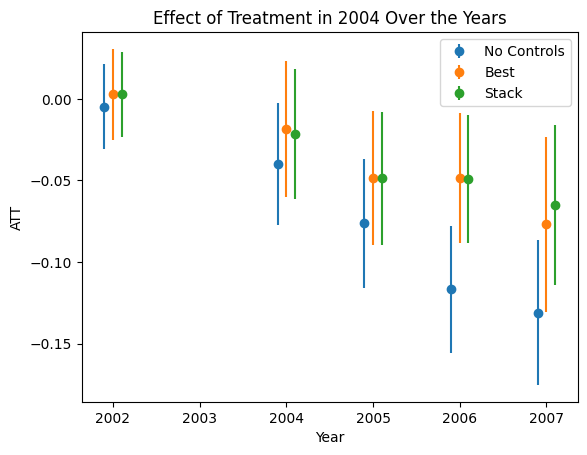

In [11]:
import matplotlib.pyplot as plt

table_all = pd.concat([table2002, table2], axis=1)
years_plot = np.array([2002, 2004, 2005, 2006, 2007])
for it, method in enumerate(['No Controls', 'Best', 'Stack']):
    plt.errorbar(years_plot + (it - 1) * .1,
                 np.array([table_all[year]['att'].loc[method] for year in years_plot]),
                 yerr=1.96 * np.array([table_all[year]['se'].loc[method] for year in years_plot]),
                 fmt='o', label=method)
plt.legend()
plt.xlabel('Year')
plt.ylabel('ATT')
plt.title('Effect of Treatment in 2004 Over the Years')
plt.show()


### Discussion

**ATT magnitude versus the baseline.** Every covariate-adjusted method produces a smaller (less negative) ATT than "No Controls" in every year. For example, in 2007 "No Controls" estimates an ATT of -0.131, while the covariate-adjusted methods range from -0.062 (Lasso) to -0.077 (Best), roughly half the baseline's magnitude. The same pattern holds in 2004-2006. This confirms what we expected: ignoring baseline county characteristics overstates the negative employment effect, because counties that raised their minimum wage were not identical, on average, to counties that did not, even before treatment.

**RMSE improvements.** For the outcome model (RMSE dy), nearly every covariate-adjusted method beats "No Controls" in nearly every year, though the gap is modest (for example in 2007: 0.230 for "No Controls" versus about 0.221-0.223 for the other methods). The one exception is Random Forest in 2004, where its RMSE dy (0.165) is slightly *worse* than "No Controls" (0.163), likely just noise given how small the gap is. For the treatment model (RMSE D), most methods improve on "No Controls," with one consistent exception: Lasso's treatment-model RMSE is *worse* than "No Controls" in every year (0.209 vs 0.198 in 2004, 0.209 vs 0.201 in 2005, 0.225 vs 0.211 in 2006, and 0.274 vs 0.250 in 2007). This suggests the L1-penalized logistic model is not well suited to predicting treatment status here, likely because the penalty shrinks too many of the third-order polynomial interaction terms to zero and loses signal.

**Recommended method.** "Stack" and "Best" are the most defensible choices for a final model. Both are ensembles built directly from the individual learners' out-of-fold predictions, so they are never worse, in principle, than the single best-performing method, and they smooth over the instability of picking one method by RMSE alone in a single sample. In our results, "Stack" produces the lowest or near-lowest RMSE for the outcome model in every year, and both ensembles fall within a similar range of ATT estimates as Basic, Expansion, Ridge, and Random Forest, which is reassuring since it means the covariate-adjusted answer does not hinge on picking one specific functional form. We would recommend "Stack" as the headline result, with the full method comparison shown for transparency.

**Pre-trends check.** The 2002 placebo test estimates are close to zero for every method (ranging from -0.005 to 0.010) with standard errors around 0.013-0.022, so none are statistically distinguishable from zero. This supports the conditional parallel trends assumption underlying the DiD design, and gives us more confidence in the 2004-2007 estimates above.

## Heterogeneity Analysis

The estimates above give a single average treatment effect on the treated for each year. As an extension, we examine whether the effect of the minimum wage increase varies across counties, using a Causal Forest. This lets the treatment effect depend on county characteristics (baseline employment, population, average pay, region), rather than assuming one constant effect for all treated counties.

We use `econml`'s `CausalForestDML`, which combines the same doubly robust DML logic used above with a forest-based estimator for the treatment effect function itself.

In [12]:
# !pip install econml

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

het_results = {}

for year in [2004, 2005, 2006, 2007]:
    X = did_data[year].drop(columns=["treated", "dy"])
    D = did_data[year].treated.values
    dy = did_data[year].dy.values

    cf = CausalForestDML(
        model_y=RandomForestRegressor(n_estimators=100, min_samples_leaf=20, max_features=4,
                                       n_jobs=-1, random_state=123),
        model_t=RandomForestClassifier(n_estimators=100, min_samples_leaf=20, max_features=4,
                                        n_jobs=-1, random_state=123),
        discrete_treatment=True,
        cv=5,
        random_state=123,
    )
    cf.fit(dy, D, X=X, W=None)

    het_results[year] = cf
    ate = cf.ate(X)
    ate_interval = cf.ate_interval(X)
    print(f"Year {year}: ATE = {ate:.4f}, 95% CI = ({ate_interval[0]:.4f}, {ate_interval[1]:.4f})")


Year 2004: ATE = -0.0320, 95% CI = (-0.3529, 0.2889)
Year 2005: ATE = -0.0727, 95% CI = (-0.3609, 0.2154)
Year 2006: ATE = -0.0714, 95% CI = (-0.3914, 0.2486)
Year 2007: ATE = -0.1021, 95% CI = (-0.3924, 0.1882)


To see which county characteristics drive heterogeneity in the treatment effect, we can inspect feature importances from the forest, and plot how the estimated effect varies with a chosen covariate, for example baseline population.

In [13]:
year = 2007
cf = het_results[year]
X = did_data[year].drop(columns=["treated", "dy"])

importances = pd.Series(cf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances


,0
lpop_0,0.400685
lavg_pay_0,0.226064
region_3,0.197416
lemp_0,0.175447
region_4,0.000387


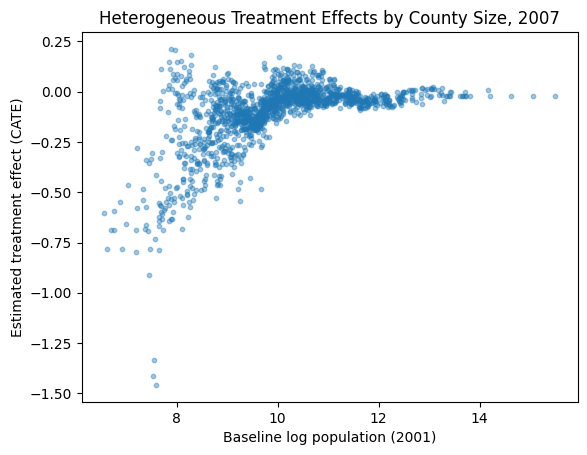

In [14]:
X_sorted = X.sort_values("lpop_0")
cate_pred = het_results[year].effect(X_sorted)

plt.scatter(X_sorted["lpop_0"], cate_pred, alpha=0.4, s=10)
plt.xlabel("Baseline log population (2001)")
plt.ylabel("Estimated treatment effect (CATE)")
plt.title(f"Heterogeneous Treatment Effects by County Size, {year}")
plt.show()


In [15]:
cate_std = cate_pred.std()
cate_min = cate_pred.min()
cate_max = cate_pred.max()
corr_lpop = np.corrcoef(cate_pred, X_sorted["lpop_0"])[0, 1]
corr_pay = np.corrcoef(cate_pred, X_sorted["lavg_pay_0"])[0, 1]

print(f"CATE range: {cate_min:.3f} to {cate_max:.3f}, std = {cate_std:.3f}")
print(f"Correlation with baseline population: {corr_lpop:.3f}")
print(f"Correlation with baseline average pay: {corr_pay:.3f}")

CATE range: -1.458 to 0.213, std = 0.163
Correlation with baseline population: 0.546
Correlation with baseline average pay: 0.353


### Discussion

**Overall ATE from the Causal Forest.** The Causal Forest's average treatment effect estimates are broadly consistent with the doubly robust DML estimates above (for example -0.032 in 2004 and -0.102 in 2007, versus roughly -0.02 and -0.07 for the covariate-adjusted DML methods), following the same pattern of a growing negative effect over time.

**Confidence intervals are wide.** The 95% confidence intervals for the ATE are wide and include zero in every year (for example, 2007: -0.392 to 0.188). This is expected: partitioning the data to also estimate effect heterogeneity uses the sample less efficiently than estimating a single average effect, so the Causal Forest is a less precise tool for pinning down the *average* effect than the DML estimators above. Its value lies in the heterogeneity it can uncover, not in a sharper ATE.

**Evidence of heterogeneity.** The individual-level treatment effect estimates (CATEs) show real spread rather than collapsing to a single number: in 2007 the estimated effects range from -1.458 to 0.213, with a standard deviation of 0.163, much wider than the average of -0.10 would suggest on its own. Feature importances point to baseline county population (`lpop_0`) as the strongest driver of this heterogeneity in 2007 (importance of 0.40, versus 0.18-0.23 for the other covariates), followed by baseline average pay and baseline employment. The correlation between the estimated 2007 effect and baseline population is 0.546, and with baseline average pay is 0.353, both positive. This suggests the negative employment effect of the minimum wage increase is concentrated in smaller, lower-population counties, and eases somewhat in larger or higher-pay counties, plausibly because larger local labor markets or already higher-paying counties have more slack to absorb a wage floor increase without cutting teen employment as sharply.

**How this extension adds value.** The single ATT numbers from the DML-DiD section tell us the effect is negative and grows over time on average, but they mask the fact that some counties may see little to no effect while others see a much larger drop. The Causal Forest results suggest county size is a meaningful moderator of the policy's impact, which is a more policy-relevant finding than the average alone. That said, given how wide the CATE range is (-1.458 to 0.213) relative to the average, and given that the ATE confidence intervals themselves are wide, these heterogeneity patterns should be read as suggestive rather than conclusive, and would benefit from a larger sample or a longer panel to sharpen the estimates.